In [ ]:
!pip install planetterp

In [ ]:
import planetterp
import pandas as pd

#professors
professor_list = ["Nelson Padua-Perez", "Ilchul Yoon", "Larry Herman", "Justin Wyss-Gallifent", "Patrick Brosnan"]

#row to be created
rows = []

#looping through each prof
for prof in professor_list:
    prof_data = planetterp.professor(name=prof, reviews=True)
    #for each review make a new row
    for review in prof_data["reviews"]:
        text = review.get("review", "")
        rating = review.get("rating")
        rows.append({
            "professor": prof,
            "text": text,
            "rating": rating
            })

df = pd.DataFrame(rows)
print(df.head())
df.to_csv("professor.csv", index=False)



            professor                                               text  \
0  Nelson Padua-Perez  Nelson is a great guy! His personality is so n...   
1  Nelson Padua-Perez  Nelson is absolutely and unequivocally the wor...   
2  Nelson Padua-Perez  People told me Nelson was awesome before I cho...   
3  Nelson Padua-Perez  Nelson is a wonderfully funny professor who re...   
4  Nelson Padua-Perez  In my opinion, Nelson is a solid CS professor....   

   rating  
0       4  
1       1  
2       3  
3       5  
4       4  


In [ ]:
!pip install transformers


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
#Multiple models can be tried, mistral, qwen, llama
model_name = "mistralai/Mistral-7B-Instruct-v0.2"
#Create model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float32
)


In [ ]:
import re
#predicts stars based of the text
def predict_stars(review_text):
    prompt = (
        "Give a single number of stars, between 1 and 5, that you think this review is assigning. "
        "Only output the number, nothing else.\n\n"
        f"Review: {review_text}\n\nStars:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False
        )

    generated_tokens = output[0, inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(generated_tokens, skip_special_tokens=True)


    match = re.search(r"\b([1-5])\b", decoded)
    return int(match.group(1)) if match else None


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()
#Predicts the rating
df["predicted_rating"] = df["text"].progress_apply(predict_stars)


In [ ]:
import numpy as np
#Shows without fine tuning the results of predicting
from sklearn.metrics import classification_report, confusion_matrix

#Drop rows where prediction failed
df = df.dropna(subset=["predicted_rating"])
df["match"] = df["rating"] == df["predicted_rating"]

#Classification report
print("Classification Report:")
print(classification_report(df["rating"], df["predicted_rating"], digits=2))


Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.81      0.80       205
           2       0.46      0.49      0.47       107
           3       0.36      0.59      0.44       116
           4       0.43      0.37      0.40       165
           5       0.94      0.83      0.88       530

    accuracy                           0.70      1123
   macro avg       0.60      0.62      0.60      1123
weighted avg       0.73      0.70      0.71      1123



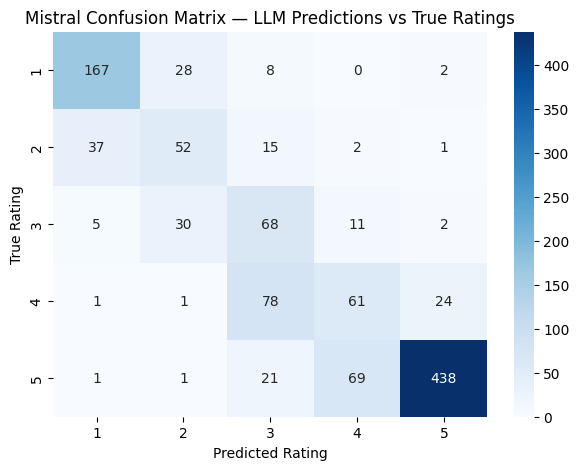

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(df["rating"], df["predicted_rating"])

# Create labels for clarity
labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Mistral Confusion Matrix — LLM Predictions vs True Ratings")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.show()


In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.nn as nn


df["label"] = df["rating"].astype(int) - 1


#Split into traiing data, test data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


labels_np = np.array(train_labels)
#Makes class weights adjusted
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_np),
    y=labels_np
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

#Choose different models here
MODEL_NAME = "roberta-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_dataset = ReviewsDataset(train_texts, train_labels, tokenizer)
val_dataset   = ReviewsDataset(val_texts,   val_labels,   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)


Class weights: tensor([1.0951, 2.1129, 1.9312, 1.3606, 0.4236], device='cuda:0')


In [ ]:
from transformers import AutoModelForSequenceClassification
from tqdm.auto import tqdm
from torch.optim import AdamW
import torch

num_labels = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Assigns the model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 70  # try more epochs to generate visualization

train_losses = []
val_accuracies = []

#Loop through epochs
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        logits = outputs.logits
        loss = loss_fn(logits, batch["labels"])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - val"):
            labels = batch["labels"].to(device)
            inp = {k: v.to(device) for k, v in batch.items() if k != "labels"}

            outputs = model(**inp)
            preds = torch.argmax(outputs.logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_acc={val_acc:.4f}")


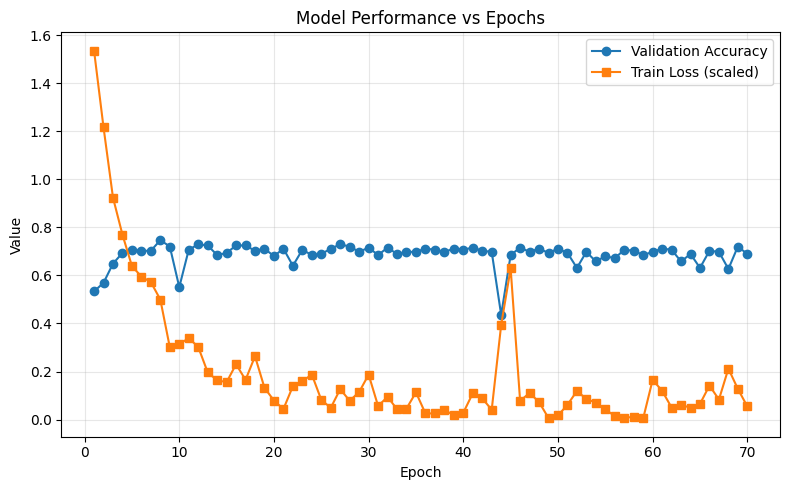

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, val_accuracies, marker="o", label="Validation Accuracy")
plt.plot(epochs_range, train_losses, marker="s", label="Train Loss (scaled)")
# if loss is much larger/smaller than accuracy, you can divide it by a constant:
# plt.plot(epochs_range, [l/5 for l in train_losses], marker="s", label="Train Loss / 5")

plt.title("Model Performance vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_true = []
all_pred = []
#Report the accuracy with confusion matrix
with torch.no_grad():
    for batch in val_loader:
        labels = batch["labels"].numpy()
        inp = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        outputs = model(**inp)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_true.extend(labels)
        all_pred.extend(preds)

true_stars = [l+1 for l in all_true]
pred_stars = [p+1 for p in all_pred]

print(classification_report(true_stars, pred_stars))
print(confusion_matrix(true_stars, pred_stars))


              precision    recall  f1-score   support

           1       0.73      0.78      0.75        41
           2       0.53      0.36      0.43        22
           3       0.45      0.39      0.42        23
           4       0.39      0.58      0.46        33
           5       0.90      0.82      0.86       106

    accuracy                           0.69       225
   macro avg       0.60      0.59      0.58       225
weighted avg       0.71      0.69      0.69       225

[[32  5  2  0  2]
 [ 7  8  6  1  0]
 [ 1  2  9 11  0]
 [ 3  0  3 19  8]
 [ 1  0  0 18 87]]


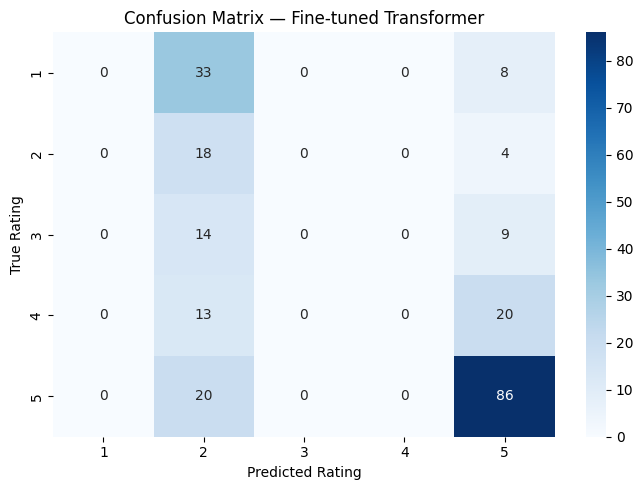

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix from your lists
cm = confusion_matrix(true_stars, pred_stars)
labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Fine-tuned Transformer")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.tight_layout()
plt.show()


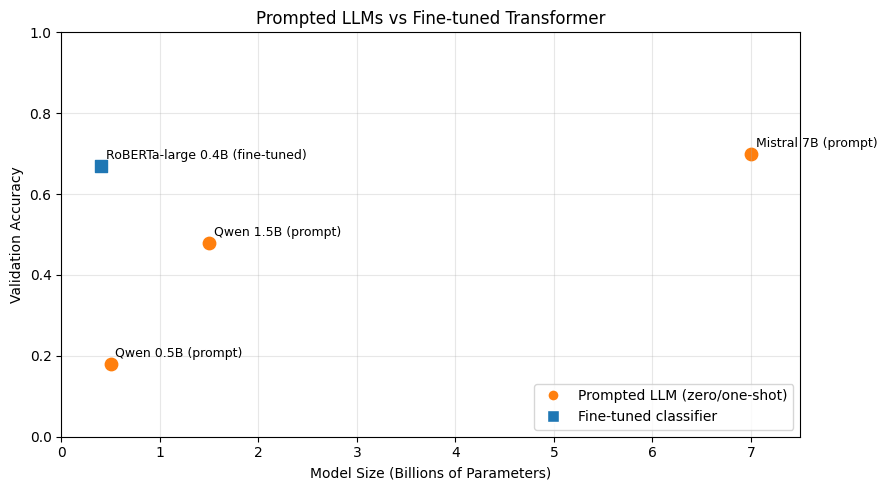

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = [
    "Qwen 0.5B (prompt)",
    "Qwen 1.5B (prompt)",
    "Mistral 7B (prompt)",
    "RoBERTa-large 0.4B (fine-tuned)",
]

# model sizes in billions of parameters
params_billion = [0.5, 1.5, 7.0, 0.4]

# validation accuracies you measured (example values)
accuracies = [0.18, 0.48, 0.70, 0.67]

# color/marker by approach: prompted LLM vs fine-tuned
colors  = ["tab:orange", "tab:orange", "tab:orange", "tab:blue"]
markers = ["o",           "o",           "o",           "s"]

plt.figure(figsize=(9,5))

for name, p, acc, c, m in zip(models, params_billion, accuracies, colors, markers):
    plt.scatter(p, acc, color=c, s=80, marker=m)
    # small text label next to each point
    plt.text(p + 0.05, acc + 0.01, name, fontsize=9, va="bottom")

plt.xlabel("Model Size (Billions of Parameters)")
plt.ylabel("Validation Accuracy")
plt.title("Prompted LLMs vs Fine-tuned Transformer")
plt.ylim(0.0, 1.0)
plt.xlim(0, max(params_billion) + 0.5)
plt.grid(alpha=0.3)

# custom legend
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           label='Prompted LLM (zero/one-shot)',
           markerfacecolor='tab:orange', markersize=8),
    Line2D([0],[0], marker='s', color='w',
           label='Fine-tuned classifier',
           markerfacecolor='tab:blue', markersize=8),
]
plt.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()


/tmp/ipython-input-3772894878.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=accuracies, palette=["#FFCA28", "#17A2B8"])


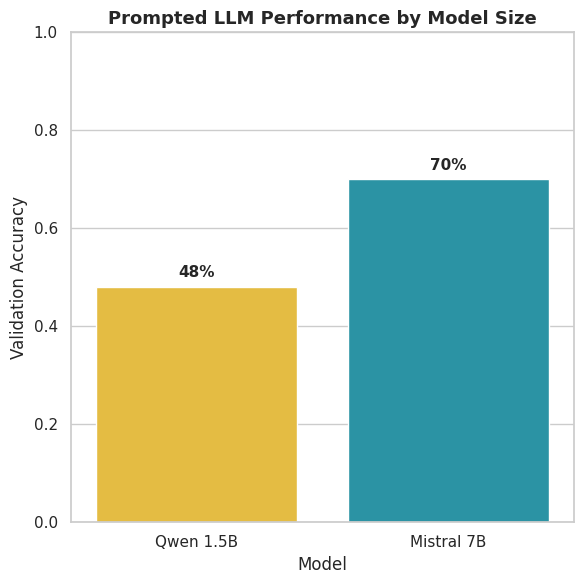

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
models = ["Qwen 1.5B", "Mistral 7B"]
accuracies = [0.48, 0.70]

# Style
sns.set(style="whitegrid")
plt.figure(figsize=(6,6))

# Bar chart
bars = sns.barplot(x=models, y=accuracies, palette=["#FFCA28", "#17A2B8"])

# Add accuracy labels on top
for i, val in enumerate(accuracies):
    plt.text(i, val + 0.02, f"{val*100:.0f}%", ha='center', fontsize=11, weight='bold')

# Titles and labels
plt.title("Prompted LLM Performance by Model Size", fontsize=13, weight='bold')
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.0)
plt.xlabel("Model")
plt.tight_layout()
plt.show()
